<h1 style="font-size:32px; font-weight:800; margin-bottom:4px;">Milestone 3 — Model Development (Simplified)</h1>
<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">Rossmann Store Sales Forecasting</h3>

This notebook picks up exactly where **Milestone 2** left off. It loads the fully engineered dataset and the consensus feature list Milestone 2 produced, trains three models, and compares them.

**Models trained:** Linear Regression (baseline), Random Forest, XGBoost, plus a simple Ensemble (average of Random Forest and XGBoost).
**Not included:** LSTM / deep learning — removed on purpose to keep this notebook shorter and easier to follow.
**Also included:** model explainability (XAI) using SHAP, Permutation Importance, and ICE plots, plus saving the final chosen model as a single `.pkl` file ready for deployment.

**A note on "accuracy":** this is a regression problem (predicting an actual Sales number), not a classification problem, so there is no such thing as a 0-100% accuracy score in the usual sense. The closest equivalent is **R² (R-squared)**, which ranges from 0 to 1 and measures how much of the variation in Sales the model explains. Throughout this notebook, "accuracy" refers to R².

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">1. Setup</h2>
Imports, a fixed random seed for reproducibility, and a consistent dark-mode chart style used throughout the notebook.

In [5]:
!pip install xgboost
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DARK_BG  = "#0e1117"
PANEL_BG = "#161a23"
GRID_CLR = "#2a2f3a"
TEXT_CLR = "#e8e8e8"
ACCENT   = ["#00d4ff", "#ff2e63", "#08d9d6", "#f8b400", "#7b2ff7"]

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": PANEL_BG,
    "axes.edgecolor": GRID_CLR,
    "axes.labelcolor": TEXT_CLR,
    "text.color": TEXT_CLR,
    "xtick.color": TEXT_CLR,
    "ytick.color": TEXT_CLR,
    "grid.color": GRID_CLR,
    "grid.alpha": 0.4,
    "axes.grid": True,
    "font.size": 11,
    "savefig.facecolor": DARK_BG,
    "legend.facecolor": PANEL_BG,
    "legend.edgecolor": GRID_CLR,
})
sns.set_palette(ACCENT)

def style_spines(ax):
    for spine in ax.spines.values():
        spine.set_color(GRID_CLR)

print("Environment ready. Random seed fixed at", RANDOM_STATE)

Environment ready. Random seed fixed at 42


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">2. Load the Milestone 2 Output</h2>
This is the exact cleaned, feature-engineered dataset produced at the end of Milestone 2 — nothing is re-cleaned or re-engineered here.

In [6]:
DATA_PATH = 'cleaned_final_rossmann_data_m2.zip'

df = pd.read_csv(DATA_PATH, compression="zip")
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Date", "Store"]).reset_index(drop=True)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Stores: {df['Store'].nunique()}")
df.head()

Dataset shape: 844,392 rows x 50 columns
Date range: 2013-01-01 -> 2015-07-31
Stores: 1115


,Store,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,Sales_RollingMean_30,Sales_RollingStd_7,Sales_Lag_14,Month_sin,Month_cos,DayOfWeek_num,DOW_sin,DOW_cos,IsWeekend,Store_Month_AvgSales
0,85,2013-01-01,4220,619,1,0,1,1,-0.534564,10,...,0.128016,0.808662,0.106668,0.5,0.866025,2,0.974928,-0.222521,0,-0.106964
1,259,2013-01-01,6851,1444,1,0,1,1,-0.853576,0,...,1.857475,0.663323,1.544995,0.5,0.866025,2,0.974928,-0.222521,0,1.320917
2,262,2013-01-01,17267,1454,1,0,1,1,-0.667165,5,...,5.497861,3.350190,4.485054,0.5,0.866025,2,0.974928,-0.222521,0,4.694189
3,274,2013-01-01,3102,729,1,0,1,1,-0.194412,0,...,-1.170520,-0.356210,-0.941135,0.5,0.866025,2,0.974928,-0.222521,0,-1.499111
4,335,2013-01-01,2401,482,1,0,1,1,-0.876637,0,...,2.543736,3.342050,2.079239,0.5,0.866025,2,0.974928,-0.222521,0,2.470988


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">3. Feature List</h2>
This is the Milestone 2 consensus feature list, written directly here rather than loaded from a separate file — one less file to keep track of, and it is always exactly in sync with what this notebook trains on.

In [7]:
feature_cols = [
    "Promo", "Promo2Active", "StateHoliday", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpen",
    "DayOfWeek_2", "DayOfWeek_3", "DayOfWeek_4", "DayOfWeek_5", "DayOfWeek_6", "DayOfWeek_7",
    "Month", "Quarter", "Month_sin", "Month_cos", "DOW_sin", "DOW_cos", "IsWeekend",
    "StoreType_b", "StoreType_c", "StoreType_d", "Assortment_b", "Assortment_c",
    "Sales_Lag_7", "Sales_Lag_14", "Sales_Lag_30",
    "Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7",
    "Store_Month_AvgSales",
]


feature_cols = [c for c in feature_cols if c in df.columns]
missing = [c for c in [
    "Promo", "Promo2Active", "StateHoliday", "SchoolHoliday",
    "CompetitionDistance", "CompetitionOpen",
    "DayOfWeek_2", "DayOfWeek_3", "DayOfWeek_4", "DayOfWeek_5", "DayOfWeek_6", "DayOfWeek_7",
    "Month", "Quarter", "Month_sin", "Month_cos", "DOW_sin", "DOW_cos", "IsWeekend",
    "StoreType_b", "StoreType_c", "StoreType_d", "Assortment_b", "Assortment_c",
    "Sales_Lag_7", "Sales_Lag_14", "Sales_Lag_30",
    "Sales_RollingMean_7", "Sales_RollingMean_30", "Sales_RollingStd_7",
    "Store_Month_AvgSales",
] if c not in df.columns]
if missing:
    print("Note: these expected columns were not found in the data and were skipped:", missing)

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

X = df[feature_cols]
y = df["Sales"]

Using 31 features:
['Promo', 'Promo2Active', 'StateHoliday', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpen', 'DayOfWeek_2', 'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'DayOfWeek_7', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'DOW_sin', 'DOW_cos', 'IsWeekend', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_30', 'Sales_RollingMean_7', 'Sales_RollingMean_30', 'Sales_RollingStd_7', 'Store_Month_AvgSales']


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">4. Quick Visual Check</h2>
A fast look at the overall sales trend and distribution, just to confirm the data looks healthy before any modeling starts.

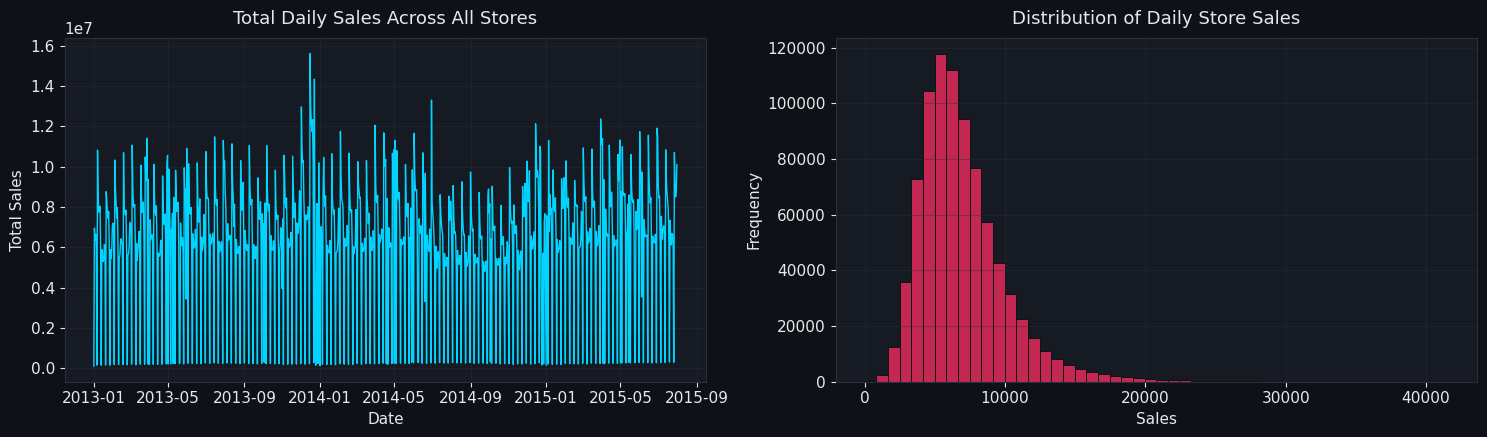

In [8]:
daily_sales = df.groupby("Date")["Sales"].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].plot(daily_sales.index, daily_sales.values, color=ACCENT[0], linewidth=1)
axes[0].set_title("Total Daily Sales Across All Stores", fontsize=13, pad=10)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total Sales")

sns.histplot(df["Sales"], bins=50, color=ACCENT[1], ax=axes[1], edgecolor=DARK_BG)
axes[1].set_title("Distribution of Daily Store Sales", fontsize=13, pad=10)
axes[1].set_xlabel("Sales")
axes[1].set_ylabel("Frequency")

for ax in axes:
    style_spines(ax)

plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">5. Chronological Train/Test Split</h2>
`TimeSeriesSplit` is used instead of a random split, so the model is always validated on dates that come *after* its training dates — never on a random shuffle. This matches how the model will actually be used: predicting the future from the past. The last fold is held out as the final test set.

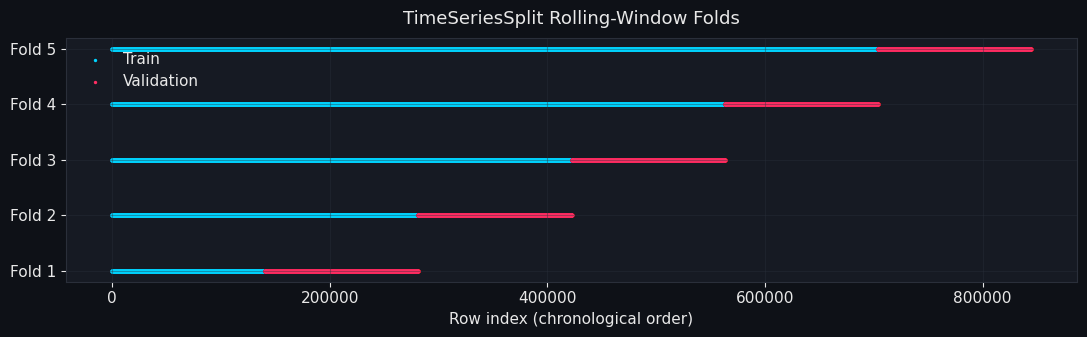

Cutoff date: 2015-02-28
Training set: 703,660 rows (2013-01-01 -> 2015-02-28)
Test set: 140,732 rows (2015-02-28 -> 2015-07-31)


In [9]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X))

fig, ax = plt.subplots(figsize=(11, 3.5))
for i, (tr_idx, te_idx) in enumerate(splits):
    ax.scatter(tr_idx, [i] * len(tr_idx), c=ACCENT[0], s=2, label="Train" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c=ACCENT[1], s=2, label="Validation" if i == 0 else None)
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Row index (chronological order)")
ax.set_title("TimeSeriesSplit Rolling-Window Folds", fontsize=13, pad=10)
ax.legend(loc="upper left", frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

train_index, test_index = splits[-1]
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
cutoff_date = df.iloc[test_index[0]]["Date"]

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Training set: {X_train.shape[0]:,} rows ({df.iloc[train_index[0]]['Date'].date()} -> {df.iloc[train_index[-1]]['Date'].date()})")
print(f"Test set: {X_test.shape[0]:,} rows ({df.iloc[test_index[0]]['Date'].date()} -> {df.iloc[test_index[-1]]['Date'].date()})")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">6. Metrics Helper</h2>
One function computes all five metrics for every model, so results stay directly comparable. **R2 is the "accuracy" number to focus on.**

In [10]:
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2, "MAPE": mape}

results = {}
predictions = {}

<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">6.1 Diagnostics Helpers: Learning Curves & Train-vs-Test Comparison</h3>

Two reusable helpers are defined once and used after every model below:

- **`plot_train_vs_test(...)`** — trains and test metrics side by side for a single model. A large gap (train much better than test) signals **overfitting**; both scores being low signals **underfitting**; close and high scores signal good generalization.
- **`plot_learning_curve(...)`** — retrains the model on growing slices of the training data (using the same time-aware CV) and plots training score vs. validation score as a function of training-set size. This is the classic diagnostic for deciding whether a model would benefit from *more data* (curves still converging) or has *plateaued* (curves flat and close together).

`train_results` mirrors `results`/`predictions` but holds each model's performance on the **training** set.

In [11]:
from sklearn.model_selection import learning_curve

train_results = {}
train_predictions = {}


def plot_train_vs_test(model_name, train_metrics, test_metrics):
    """Bar-chart comparison of R2, RMSE, and MAE on train vs. test for one model."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    metric_specs = [("R2", "R\u00b2 Score (%)", 100), ("RMSE", "RMSE", 1), ("MAE", "MAE", 1)]

    for ax, (key, label, mult) in zip(axes, metric_specs):
        vals = [train_metrics[key] * mult, test_metrics[key] * mult]
        bars = ax.bar(["Train", "Test"], vals, color=[ACCENT[0], ACCENT[1]])
        ax.set_title(label, fontsize=12, pad=8)
        style_spines(ax)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:,.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 4), textcoords="offset points", ha="center",
                        color=TEXT_CLR, fontsize=9)

    fig.suptitle(f"{model_name} \u2014 Train vs. Test Performance", fontsize=14, y=1.05, fontweight="bold")
    plt.tight_layout()
    plt.show()

    gap = train_metrics["R2"] - test_metrics["R2"]
    if gap > 0.15:
        verdict = "sizeable train/test gap \u2192 likely OVERFITTING; consider more regularization or fewer features."
    elif train_metrics["R2"] < 0.5 and test_metrics["R2"] < 0.5:
        verdict = "both scores are low \u2192 likely UNDERFITTING; the model may need more capacity or better features."
    else:
        verdict = "train and test scores are close \u2192 the model is generalizing well."
    print(f"Train R\u00b2 = {train_metrics['R2']:.3f}  |  Test R\u00b2 = {test_metrics['R2']:.3f}  |  Gap = {gap:.3f}")
    print(f"Diagnosis: {verdict}")


def plot_learning_curve(estimator, X_data, y_data, title, cv_splits=3, n_points=6):
    """Training-set-size vs. R2 score, for both the training folds and the held-out validation folds."""
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X_data, y_data,
        cv=TimeSeriesSplit(n_splits=cv_splits),
        scoring="r2",
        train_sizes=np.linspace(0.1, 1.0, n_points),
        n_jobs=-1,
        shuffle=False,
    )
    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(train_sizes_abs, train_mean, color=ACCENT[0], marker="o", label="Training score")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, color=ACCENT[0], alpha=0.15)
    ax.plot(train_sizes_abs, val_mean, color=ACCENT[1], marker="o", label="Validation score")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, color=ACCENT[1], alpha=0.15)
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("R\u00b2 Score")
    ax.legend(frameon=False, loc="lower right")
    style_spines(ax)
    plt.tight_layout()
    plt.show()


print("Diagnostics helpers ready: plot_train_vs_test(), plot_learning_curve().")


Diagnostics helpers ready: plot_train_vs_test(), plot_learning_curve().


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">7. Model 1 — Linear Regression (Baseline)</h2>
A simple model to sanity-check against. Any more complex model below should clearly beat this.

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

results["Linear Regression"] = get_metrics(y_test, lr_preds)
predictions["Linear Regression"] = lr_preds

print("Linear Regression:", {k: round(v, 3) for k, v in results["Linear Regression"].items()})

Linear Regression: {'MAE': 894.153, 'MSE': 1584362.542, 'RMSE': np.float64(1258.715), 'R2': 0.836, 'MAPE': np.float64(22.798)}


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">7.1 Linear Regression — Train vs. Test & Learning Curve</h3>

A linear model has limited capacity, so a small train/test gap is expected here — the more interesting question is whether it *underfits* (both scores mediocre) compared to the tree-based models later on.

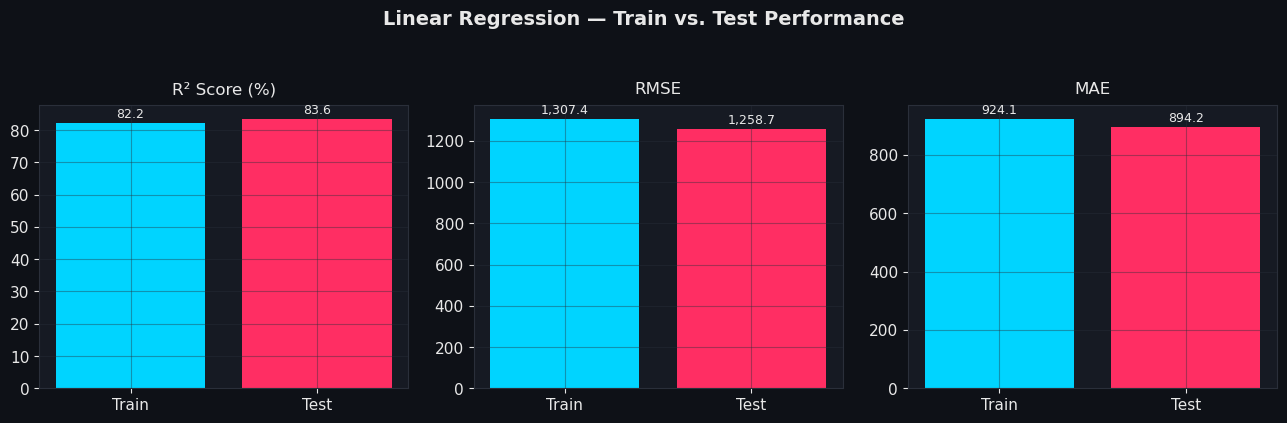

Train R² = 0.822  |  Test R² = 0.836  |  Gap = -0.014
Diagnosis: train and test scores are close → the model is generalizing well.


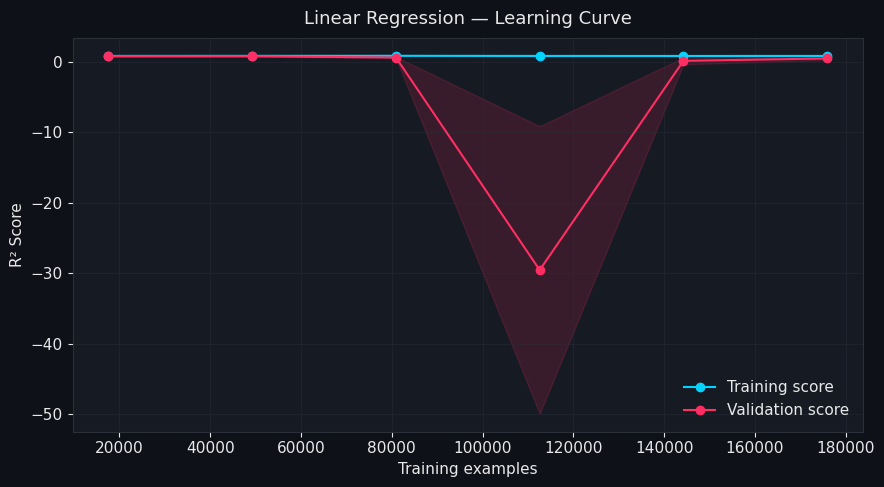

In [13]:
lr_train_preds = lr_model.predict(X_train_scaled)
train_results["Linear Regression"] = get_metrics(y_train, lr_train_preds)
train_predictions["Linear Regression"] = lr_train_preds

plot_train_vs_test("Linear Regression", train_results["Linear Regression"], results["Linear Regression"])
plot_learning_curve(LinearRegression(), X_train_scaled, y_train, "Linear Regression \u2014 Learning Curve")


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">8. Model 2 — Random Forest (Tuned)</h2>
An ensemble of decision trees. `RandomizedSearchCV` searches over a range of hyperparameters using a time-aware cross-validator (never a plain random K-Fold, which would leak future information into training).

In [14]:
rf_param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [10, 14, 18, 22, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=25,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_train_scaled, y_train)

rf_model = rf_search.best_estimator_
rf_preds = rf_model.predict(X_test_scaled)

results["Random Forest"] = get_metrics(y_test, rf_preds)
predictions["Random Forest"] = rf_preds

print("Best Random Forest params:", rf_search.best_params_)
print("Random Forest:", {k: round(v, 3) for k, v in results["Random Forest"].items()})

Best Random Forest params: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 22}
Random Forest: {'MAE': 668.378, 'MSE': 975543.148, 'RMSE': np.float64(987.696), 'R2': 0.899, 'MAPE': np.float64(19.918)}


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">8.1 Random Forest — Train vs. Test & Learning Curve</h3>

Tree ensembles can memorize training data easily, so watch the train/test gap closely here — that is exactly what `min_samples_leaf` / `max_depth` in the tuning grid above are meant to control.

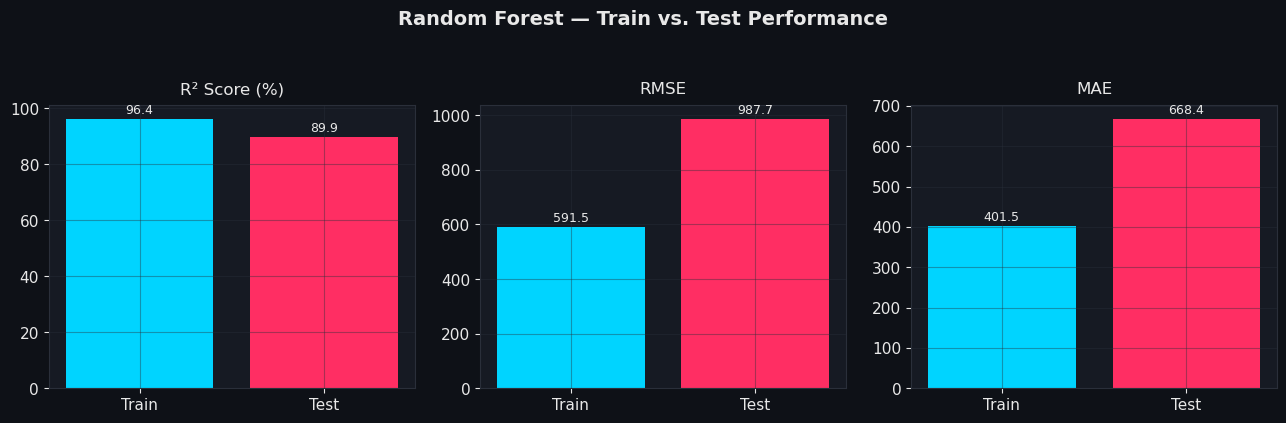

Train R² = 0.964  |  Test R² = 0.899  |  Gap = 0.065
Diagnosis: train and test scores are close → the model is generalizing well.


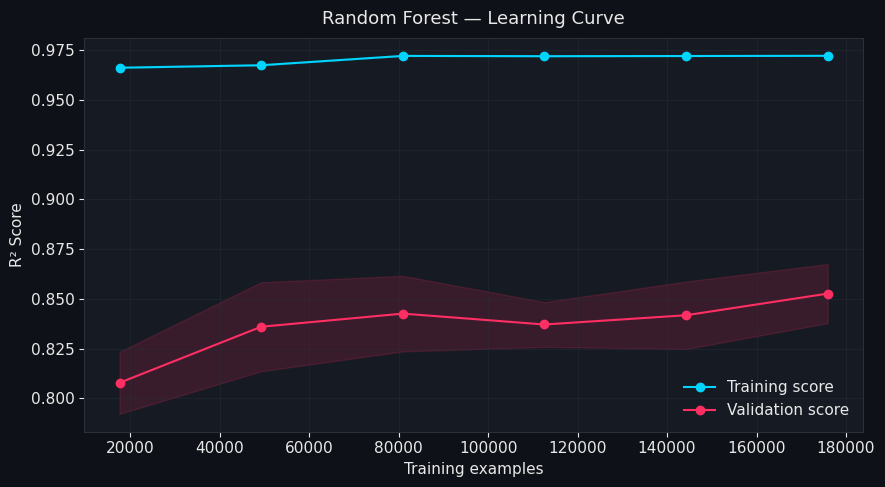

In [15]:
rf_train_preds = rf_model.predict(X_train_scaled)
train_results["Random Forest"] = get_metrics(y_train, rf_train_preds)
train_predictions["Random Forest"] = rf_train_preds

plot_train_vs_test("Random Forest", train_results["Random Forest"], results["Random Forest"])
plot_learning_curve(rf_search.best_estimator_, X_train_scaled, y_train, "Random Forest \u2014 Learning Curve")


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">9. Model 3 — XGBoost (Tuned)</h2>
Builds trees sequentially, with each new tree correcting the previous ensemble's errors. Usually the strongest single model on this kind of tabular, feature-rich data.

In [16]:
xgb_param_dist = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=TimeSeriesSplit(n_splits=3),
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
xgb_search.fit(X_train_scaled, y_train)

xgb_model = xgb_search.best_estimator_
xgb_preds = xgb_model.predict(X_test_scaled)

results["XGBoost"] = get_metrics(y_test, xgb_preds)
predictions["XGBoost"] = xgb_preds

print("Best XGBoost params:", xgb_search.best_params_)
print("XGBoost:", {k: round(v, 3) for k, v in results["XGBoost"].items()})

Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
XGBoost: {'MAE': 703.304, 'MSE': 1070371.0, 'RMSE': np.float64(1034.587), 'R2': 0.889, 'MAPE': np.float64(20.286)}


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">9.1 XGBoost — Train vs. Test & Learning Curve</h3>

XGBoost's `reg_alpha` / `reg_lambda` / `subsample` are its main defenses against overfitting — the train/test gap below is a direct readout of how well the tuned regularization is working.

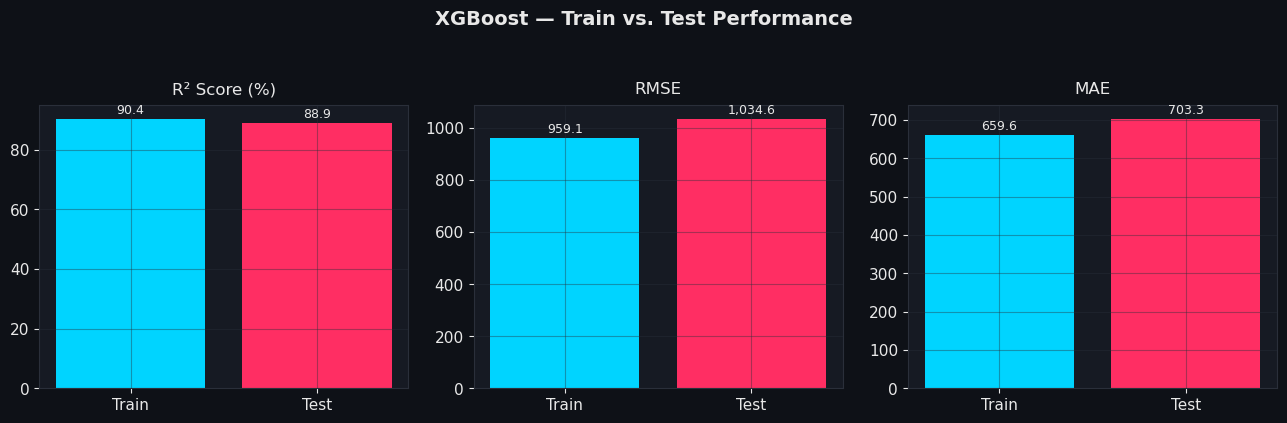

Train R² = 0.904  |  Test R² = 0.889  |  Gap = 0.015
Diagnosis: train and test scores are close → the model is generalizing well.


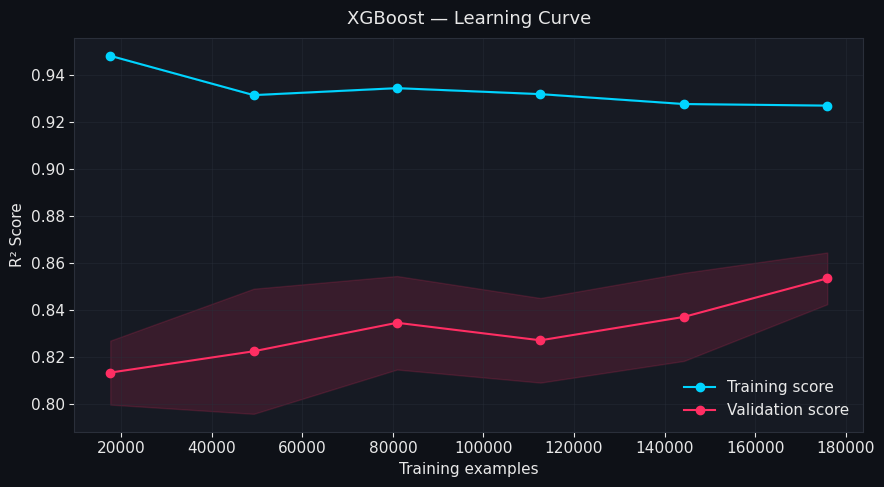

In [17]:
xgb_train_preds = xgb_model.predict(X_train_scaled)
train_results["XGBoost"] = get_metrics(y_train, xgb_train_preds)
train_predictions["XGBoost"] = xgb_train_preds

plot_train_vs_test("XGBoost", train_results["XGBoost"], results["XGBoost"])
plot_learning_curve(xgb_search.best_estimator_, X_train_scaled, y_train, "XGBoost \u2014 Learning Curve")


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">10. Bonus Model — Simple Ensemble (Random Forest + XGBoost Average)</h2>
Averaging two different models' predictions often smooths out each model's individual mistakes and can push R² a bit higher than either model alone, at essentially no extra training cost.

In [18]:
ensemble_preds = (predictions["Random Forest"] + predictions["XGBoost"]) / 2

results["Ensemble (RF + XGB)"] = get_metrics(y_test, ensemble_preds)
predictions["Ensemble (RF + XGB)"] = ensemble_preds

print("Ensemble (RF + XGB):", {k: round(v, 3) for k, v in results["Ensemble (RF + XGB)"].items()})

Ensemble (RF + XGB): {'MAE': 680.394, 'MSE': 1009042.258, 'RMSE': np.float64(1004.511), 'R2': 0.895, 'MAPE': np.float64(20.02)}


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">10.1 Ensemble — Train vs. Test Performance</h3>

A formal learning curve isn't meaningful for a fixed 50/50 average of two already-tuned models (there is no single estimator to retrain at each training-set size), but the train/test comparison below still shows whether averaging helped generalization.

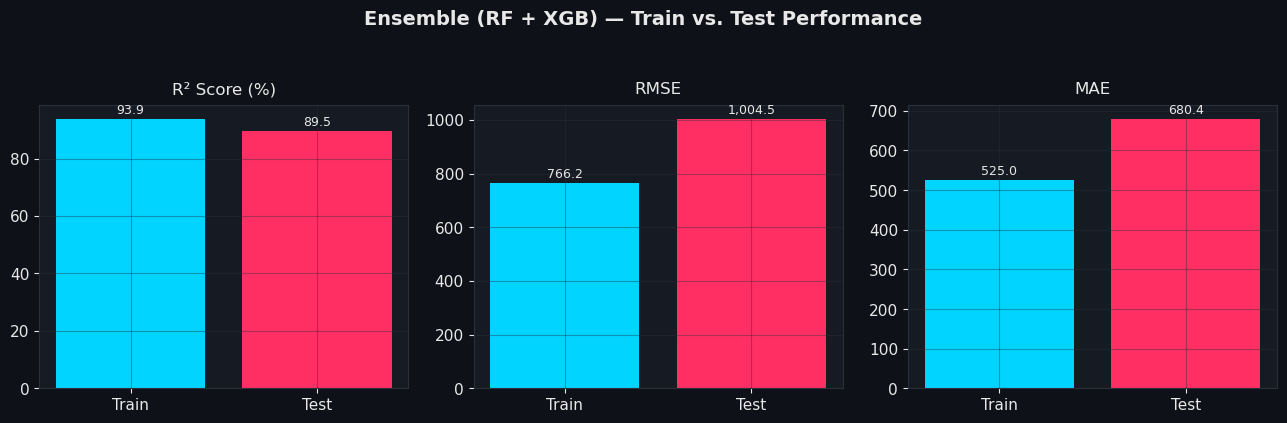

Train R² = 0.939  |  Test R² = 0.895  |  Gap = 0.044
Diagnosis: train and test scores are close → the model is generalizing well.


In [19]:
ensemble_train_preds = (train_predictions["Random Forest"] + train_predictions["XGBoost"]) / 2
train_results["Ensemble (RF + XGB)"] = get_metrics(y_train, ensemble_train_preds)
train_predictions["Ensemble (RF + XGB)"] = ensemble_train_preds

plot_train_vs_test("Ensemble (RF + XGB)", train_results["Ensemble (RF + XGB)"], results["Ensemble (RF + XGB)"])


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">11. Classical Time-Series Baseline: ARIMA & Exponential Smoothing (ETS)</h2>

The milestone brief explicitly asks for classical time-series models (ARIMA, ETS) alongside the machine-learning models above. Both are added here as a baseline comparison.

**Important framing:** ARIMA and ETS are *univariate* — they only see one number per time step, with no room for external regressors like `Promo`, `StateHoliday`, or the engineered lag features the ML models get to use. So they are fit on the **aggregated total daily sales across all stores** (one series, not one per store-day row), and to keep the comparison fair, the ML models' row-level test predictions are also aggregated to the same daily-total series before the final head-to-head comparison. Expect ARIMA/ETS to underperform the ML models here — that gap itself is a legitimate, useful finding: it quantifies how much predictive value comes specifically from the engineered features and per-store granularity.

<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">11.1 ARIMA (Grid-Searched Order)</h3>

`(p, d, q)` is selected with a small **grid search over AIC** on the training series — the same "Grid Search for hyperparameter tuning" the milestone brief asks for, applied here to a classical model instead of a tree ensemble.

In [20]:
from statsmodels.tsa.arima.model import ARIMA

daily_sales_full = df.groupby("Date")["Sales"].sum().asfreq("D").interpolate()
train_daily = daily_sales_full[daily_sales_full.index < cutoff_date]
test_daily = daily_sales_full[daily_sales_full.index >= cutoff_date]
print(f"Daily aggregate series -> train: {len(train_daily)} days, test: {len(test_daily)} days")

arima_grid = {"p": [0, 1, 2, 3], "d": [0, 1], "q": [0, 1, 2, 3]}
best_aic, best_order, best_arima_fit = np.inf, None, None

for p in arima_grid["p"]:
    for d in arima_grid["d"]:
        for q in arima_grid["q"]:
            try:
                fit = ARIMA(train_daily, order=(p, d, q)).fit()
                if fit.aic < best_aic:
                    best_aic, best_order, best_arima_fit = fit.aic, (p, d, q), fit
            except Exception:
                continue

print(f"Best ARIMA order from grid search: {best_order}  (AIC = {best_aic:.1f})")

arima_forecast = best_arima_fit.forecast(steps=len(test_daily))
arima_forecast.index = test_daily.index

ts_results = {}
ts_predictions = {}
ts_results["ARIMA"] = get_metrics(test_daily.values, arima_forecast.values)
ts_predictions["ARIMA"] = arima_forecast
print("ARIMA:", {k: round(v, 3) for k, v in ts_results["ARIMA"].items()})


Daily aggregate series -> train: 788 days, test: 154 days


E:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
E:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order from grid search: (3, 0, 3)  (AIC = 25574.1)
ARIMA: {'MAE': 2392134.207, 'MSE': 8933829855237.875, 'RMSE': np.float64(2988951.297), 'R2': 0.188, 'MAPE': np.float64(335.98)}


E:\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">11.2 Exponential Smoothing (ETS)</h3>

Same grid-search principle, this time over the trend/seasonal component types (`None`/`additive`), with a 7-day seasonal period to capture the weekly sales cycle.

In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_grid = [(t, s) for t in [None, "add"] for s in [None, "add"]]
best_aic_ets, best_cfg, best_ets_fit = np.inf, None, None

for trend, seasonal in ets_grid:
    try:
        fit = ExponentialSmoothing(
            train_daily, trend=trend, seasonal=seasonal,
            seasonal_periods=7 if seasonal else None,
        ).fit()
        if fit.aic < best_aic_ets:
            best_aic_ets, best_cfg, best_ets_fit = fit.aic, (trend, seasonal), fit
    except Exception:
        continue

print(f"Best ETS config from grid search: trend={best_cfg[0]}, seasonal={best_cfg[1]}  (AIC = {best_aic_ets:.1f})")

ets_forecast = best_ets_fit.forecast(steps=len(test_daily))
ets_forecast.index = test_daily.index

ts_results["ETS"] = get_metrics(test_daily.values, ets_forecast.values)
ts_predictions["ETS"] = ets_forecast
print("ETS:", {k: round(v, 3) for k, v in ts_results["ETS"].items()})


Best ETS config from grid search: trend=None, seasonal=add  (AIC = 22728.8)
ETS: {'MAE': 1375170.946, 'MSE': 4196010120225.376, 'RMSE': np.float64(2048416.491), 'R2': 0.619, 'MAPE': np.float64(109.049)}


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">11.3 Fair Comparison: ARIMA vs. ETS vs. Aggregated Best ML Model</h3>

The best row-level ML model's test-period predictions are summed up to the same daily granularity as ARIMA/ETS, so all three are evaluated on the identical target series.

Best ML model by test R2 so far: Random Forest


,MAE,MSE,RMSE,R2 (Accuracy %),MAPE (%)
Random Forest (aggregated),399358.79,623253988234.48,789464.37,94.34,5.89
ETS,1375170.95,4196010120225.38,2048416.49,61.88,109.05
ARIMA,2392134.21,8933829855237.88,2988951.30,18.84,335.98


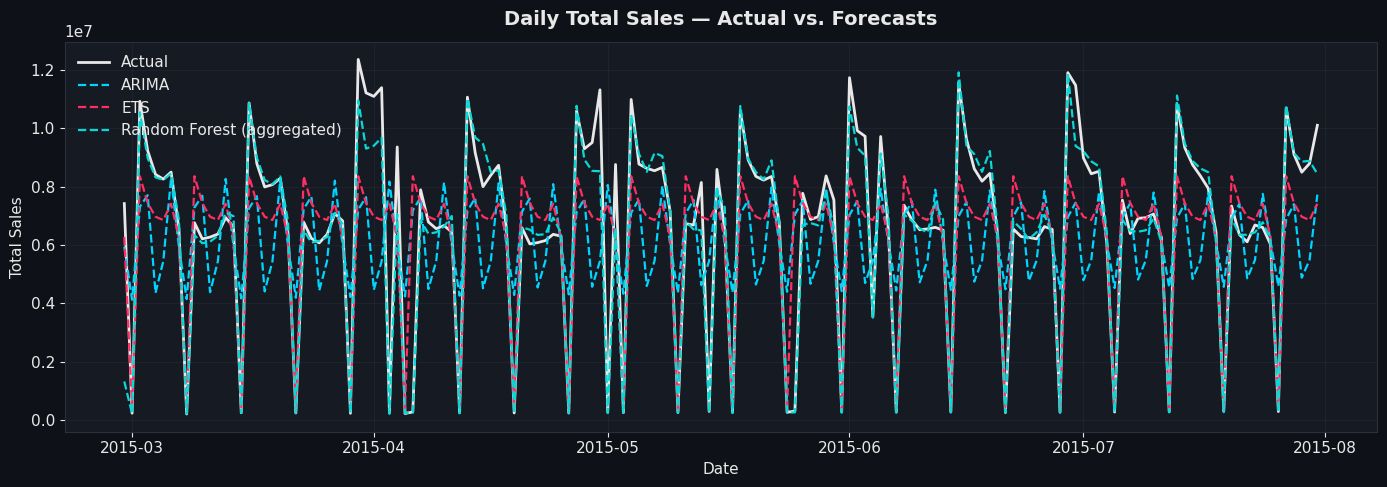

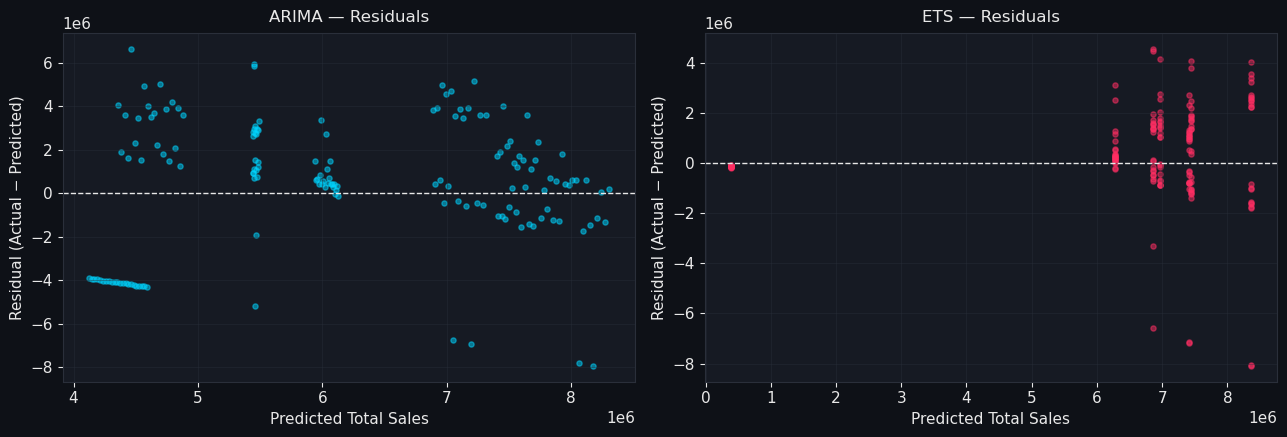

In [22]:
best_ml_model_name = max(results, key=lambda m: results[m]["R2"])
print(f"Best ML model by test R2 so far: {best_ml_model_name}")

ml_daily_pred = (
    df.iloc[test_index][["Date"]]
    .assign(Predicted=predictions[best_ml_model_name])
    .groupby("Date")["Predicted"].sum()
    .reindex(test_daily.index)
)

ts_results[f"{best_ml_model_name} (aggregated)"] = get_metrics(test_daily.values, ml_daily_pred.values)
ts_predictions[f"{best_ml_model_name} (aggregated)"] = ml_daily_pred

ts_comparison_df = pd.DataFrame(ts_results).T[["MAE", "MSE", "RMSE", "R2", "MAPE"]]
ts_comparison_df["R2"] = ts_comparison_df["R2"] * 100
ts_comparison_df = ts_comparison_df.rename(columns={"R2": "R2 (Accuracy %)", "MAPE": "MAPE (%)"})
ts_comparison_df = ts_comparison_df.sort_values("R2 (Accuracy %)", ascending=False)

display(ts_comparison_df.style.format("{:.2f}").background_gradient(
    cmap="viridis", subset=["R2 (Accuracy %)"]
).set_caption("Daily-Aggregate Forecast Comparison: Classical vs. ML"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_daily.index, test_daily.values, color=TEXT_CLR, linewidth=2, label="Actual")
for name, color in zip(ts_results.keys(), ACCENT):
    ax.plot(ts_predictions[name].index, ts_predictions[name].values, linestyle="--", linewidth=1.6, color=color, label=name)
ax.set_title("Daily Total Sales \u2014 Actual vs. Forecasts", fontsize=14, pad=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, name, color in zip(axes, ["ARIMA", "ETS"], ACCENT):
    resid = test_daily.values - ts_predictions[name].values
    ax.scatter(ts_predictions[name].values, resid, alpha=0.5, s=14, color=color)
    ax.axhline(0, color=TEXT_CLR, linestyle="--", linewidth=1)
    ax.set_title(f"{name} \u2014 Residuals", fontsize=12, pad=8)
    ax.set_xlabel("Predicted Total Sales")
    ax.set_ylabel("Residual (Actual \u2212 Predicted)")
    style_spines(ax)
plt.tight_layout()
plt.show()


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">12. Comprehensive Comparison Table</h2>
All four models side by side on the same chronological hold-out set.

In [23]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["MAE", "MSE", "RMSE", "R2", "MAPE"]]
comparison_df["R2"] = comparison_df["R2"] * 100
comparison_df = comparison_df.rename(columns={"R2": "R2 (Accuracy %)", "MAPE": "MAPE (%)"})
comparison_df = comparison_df.sort_values("R2 (Accuracy %)", ascending=False)

comparison_df.style.format("{:.2f}").background_gradient(
    cmap="viridis", subset=["R2 (Accuracy %)"]
).set_caption("Model Comparison - sorted by R2 (higher is better)")

,MAE,MSE,RMSE,R2 (Accuracy %),MAPE (%)
Random Forest,668.38,975543.15,987.70,89.89,19.92
Ensemble (RF + XGB),680.39,1009042.26,1004.51,89.54,20.02
XGBoost,703.30,1070371.00,1034.59,88.91,20.29
Linear Regression,894.15,1584362.54,1258.71,83.58,22.80


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">12.1 Train vs. Test R² — All Models Combined</h3>

Every model side by side: paired Train/Test R² bars make it immediate which models generalize well and which ones are overfitting the training data.

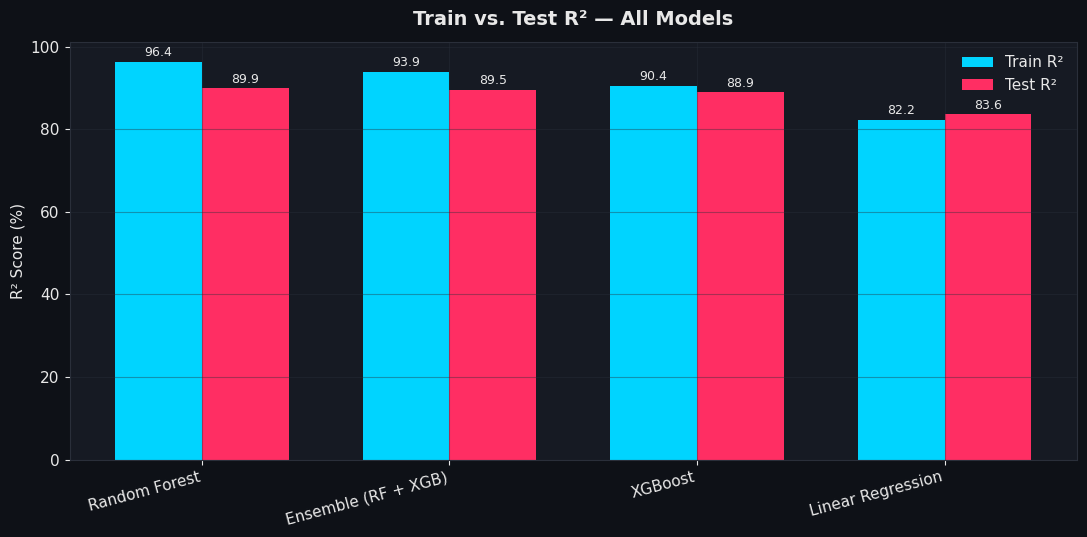

Random Forest          0.065
Ensemble (RF + XGB)    0.044
XGBoost                0.015
Linear Regression     -0.014
Name: Train-Test R2 Gap, dtype: float64


In [24]:
model_order = list(comparison_df.index)
train_r2 = [train_results[m]["R2"] * 100 for m in model_order]
test_r2 = [results[m]["R2"] * 100 for m in model_order]

x = np.arange(len(model_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))
bars_train = ax.bar(x - width / 2, train_r2, width, label="Train R\u00b2", color=ACCENT[0])
bars_test = ax.bar(x + width / 2, test_r2, width, label="Test R\u00b2", color=ACCENT[1])

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha="right")
ax.set_ylabel("R\u00b2 Score (%)")
ax.set_title("Train vs. Test R\u00b2 \u2014 All Models", fontsize=14, pad=12, fontweight="bold")
ax.legend(frameon=False)
style_spines(ax)

for bars in (bars_train, bars_test):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:,.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center",
                    color=TEXT_CLR, fontsize=9)

plt.tight_layout()
plt.show()

overfit_gap = pd.Series({m: train_results[m]["R2"] - results[m]["R2"] for m in model_order}, name="Train-Test R2 Gap")
print(overfit_gap.sort_values(ascending=False).round(3))


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">13. Residual Diagnostics</h2>
Residuals (actual minus predicted) should look like random scatter around zero, with no obvious pattern or funnel shape. A clear pattern would mean the model is systematically over- or under-predicting in some sales range.

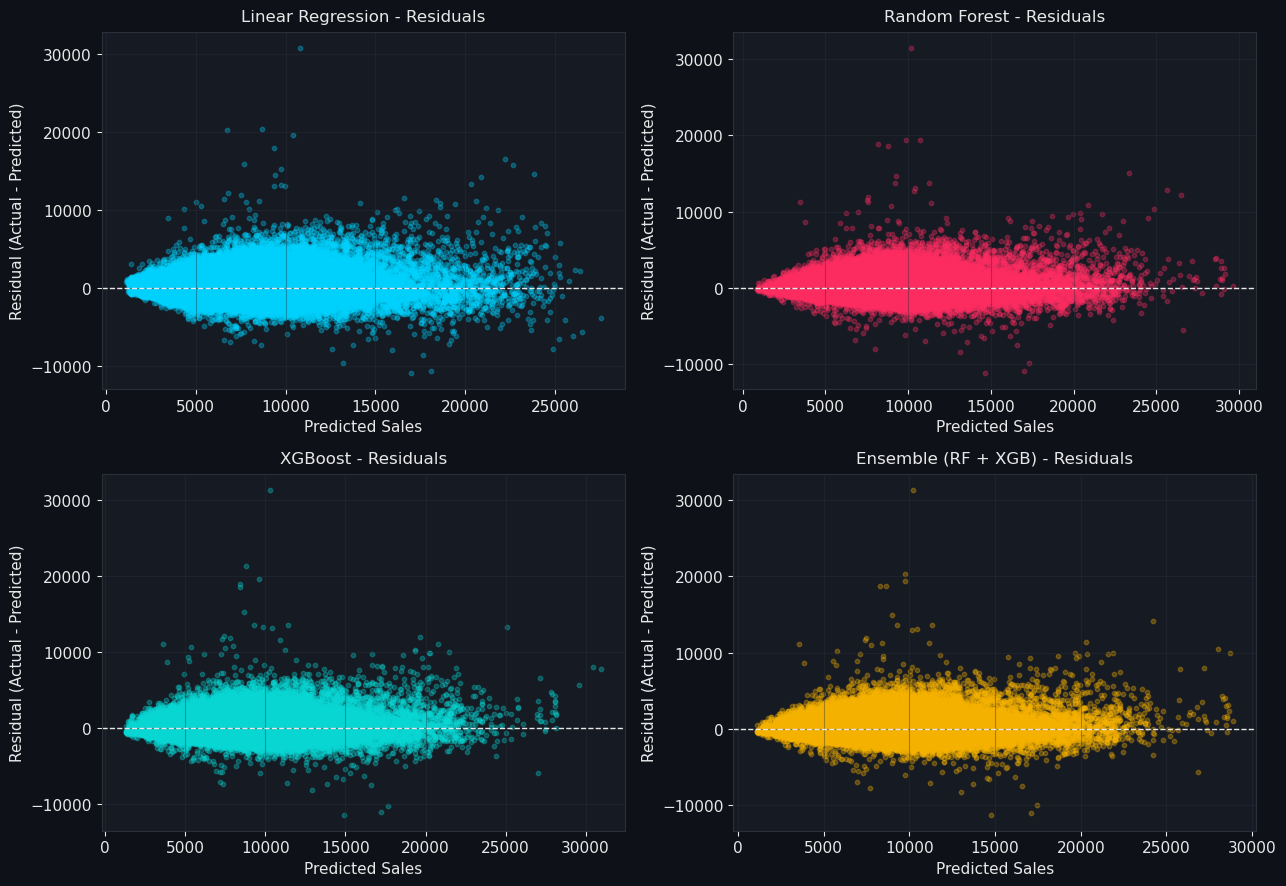

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, color) in zip(axes, zip(results.keys(), ACCENT)):
    y_pred = predictions[name]
    residuals = np.asarray(y_test) - np.asarray(y_pred)

    ax.scatter(y_pred, residuals, alpha=0.3, s=10, color=color)
    ax.axhline(0, color=TEXT_CLR, linestyle="--", linewidth=1)
    ax.set_title(f"{name} - Residuals", fontsize=12, pad=8)
    ax.set_xlabel("Predicted Sales")
    ax.set_ylabel("Residual (Actual - Predicted)")
    style_spines(ax)

plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">14. Metric Comparison Charts</h2>

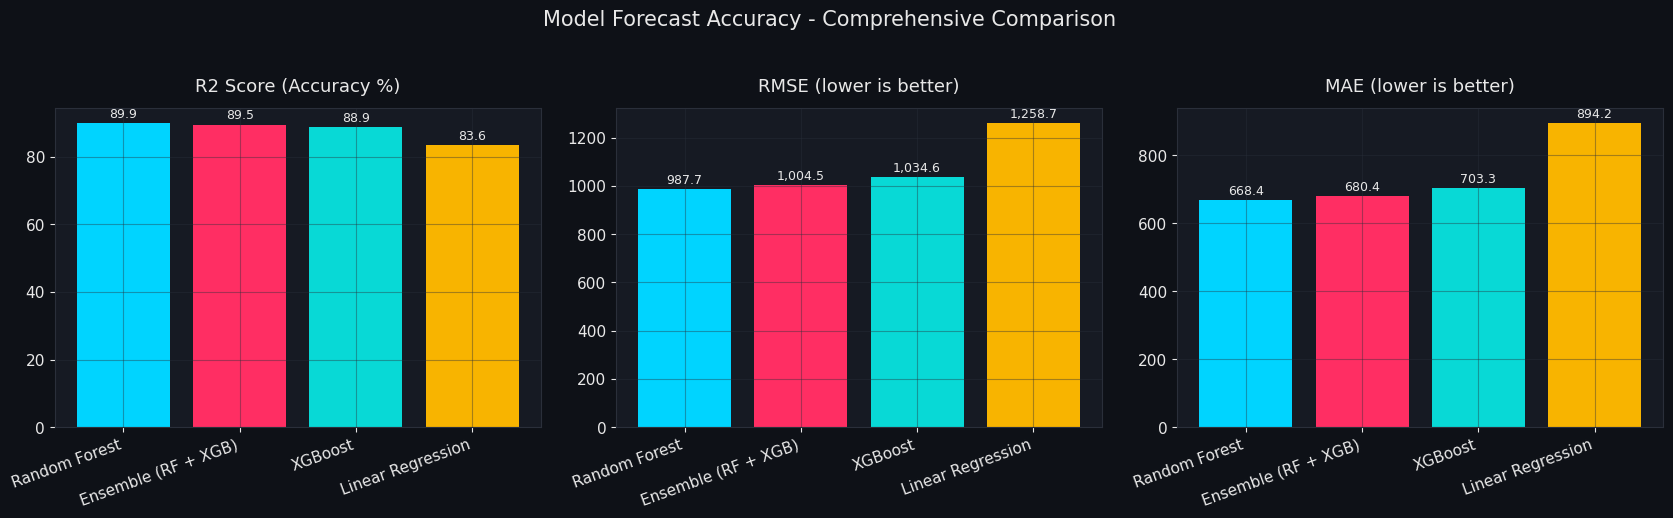

In [26]:
model_names = list(comparison_df.index)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics_to_plot = [("R2 (Accuracy %)", "R2 Score (Accuracy %)"), ("RMSE", "RMSE (lower is better)"), ("MAE", "MAE (lower is better)")]

for ax, (col, title) in zip(axes, metrics_to_plot):
    vals = comparison_df.loc[model_names, col]
    bars = ax.bar(model_names, vals, color=ACCENT[:len(model_names)])
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xticklabels(model_names, rotation=20, ha="right")
    style_spines(ax)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:,.1f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha="center",
                    color=TEXT_CLR, fontsize=9)

fig.suptitle("Model Forecast Accuracy - Comprehensive Comparison", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">15. Actual vs. Predicted Sales Over Time</h2>
The clearest possible visual check: does the predicted line actually track the real sales line on unseen dates? Shown for the single best model (by R2) on the held-out test period, for one representative store.

Best model by R2: Random Forest


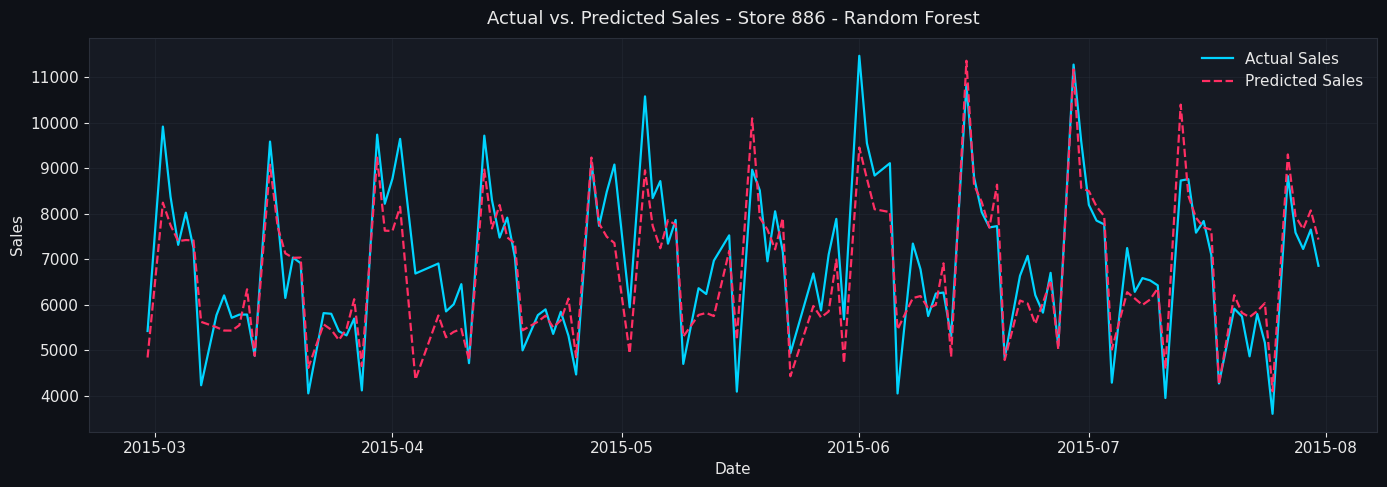

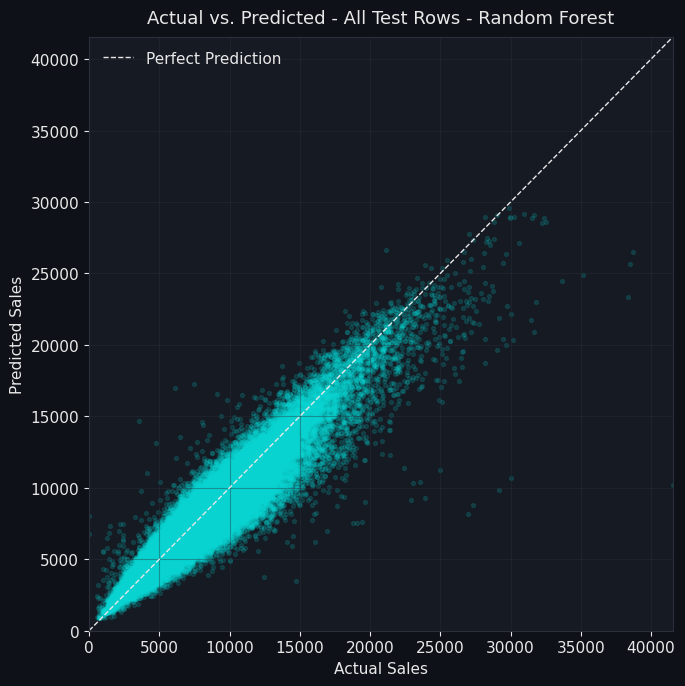

In [27]:
best_model_name = comparison_df.index[0]
print(f"Best model by R2: {best_model_name}")

plot_df = df.iloc[test_index][["Date", "Store", "Sales"]].copy()
plot_df["Predicted"] = predictions[best_model_name]

sample_store = plot_df["Store"].iloc[0]
store_plot = plot_df[plot_df["Store"] == sample_store].sort_values("Date")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store_plot["Date"], store_plot["Sales"], color=ACCENT[0], label="Actual Sales", linewidth=1.6)
ax.plot(store_plot["Date"], store_plot["Predicted"], color=ACCENT[1], label="Predicted Sales", linewidth=1.6, linestyle="--")
ax.set_title(f"Actual vs. Predicted Sales - Store {sample_store} - {best_model_name}", fontsize=13, pad=10)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, predictions[best_model_name], alpha=0.15, s=8, color=ACCENT[2])
lims = [min(y_test.min(), predictions[best_model_name].min()), max(y_test.max(), predictions[best_model_name].max())]
ax.plot(lims, lims, color=TEXT_CLR, linestyle="--", linewidth=1, label="Perfect Prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.set_title(f"Actual vs. Predicted - All Test Rows - {best_model_name}", fontsize=13, pad=10)
ax.legend(frameon=False)
style_spines(ax)
plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">16. Feature Importance (Random Forest vs. XGBoost)</h2>
Which engineered features are actually driving each model's predictions.

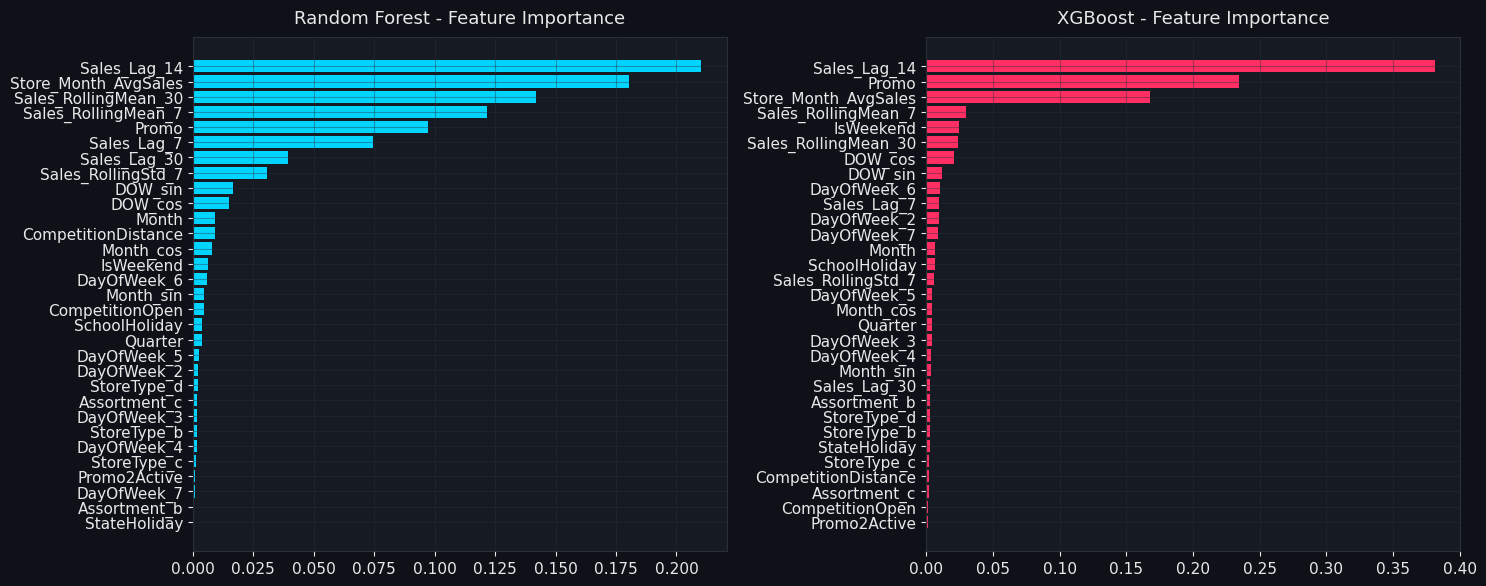

In [28]:
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(rf_importance.index, rf_importance.values, color=ACCENT[0])
axes[0].set_title("Random Forest - Feature Importance", fontsize=13, pad=10)

axes[1].barh(xgb_importance.index, xgb_importance.values, color=ACCENT[1])
axes[1].set_title("XGBoost - Feature Importance", fontsize=13, pad=10)

for ax in axes:
    style_spines(ax)

plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">17. Explainability (XAI) with SHAP</h2>
Feature importance (Section 16) shows *how much* each feature matters overall, but not *how* it pushes predictions up or down for a specific store-day. **SHAP (SHapley Additive exPlanations)** answers that: for every single prediction, it splits the difference between the model's output and its average output across all the input features, showing exactly how much each feature added or subtracted.

This section explains the XGBoost model (the strongest single tree-based model in most runs) using SHAP. The same approach works identically for Random Forest — just swap `xgb_model` for `rf_model` below.

In [29]:
!pip install shap -q

In [30]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_sample_size = min(2000, X_test.shape[0])
shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test.shape[0], shap_sample_size, replace=False)

X_test_shap = pd.DataFrame(X_test_scaled, columns=feature_cols).iloc[shap_sample_idx]
shap_values = explainer.shap_values(X_test_shap)

print(f"SHAP values computed for {shap_sample_size:,} sampled test rows.")

SHAP values computed for 2,000 sampled test rows.


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">17.1 Global Explanation — Which Features Matter Most, and In Which Direction</h3>
The summary (beeswarm) plot below shows, for every feature, how its value (color: red = high, blue = low) relates to its impact on the prediction (x-axis: SHAP value). For example, if high values of a lag feature push predictions up (red dots on the right), that confirms the model has learned the expected relationship: recent high sales predict future high sales.

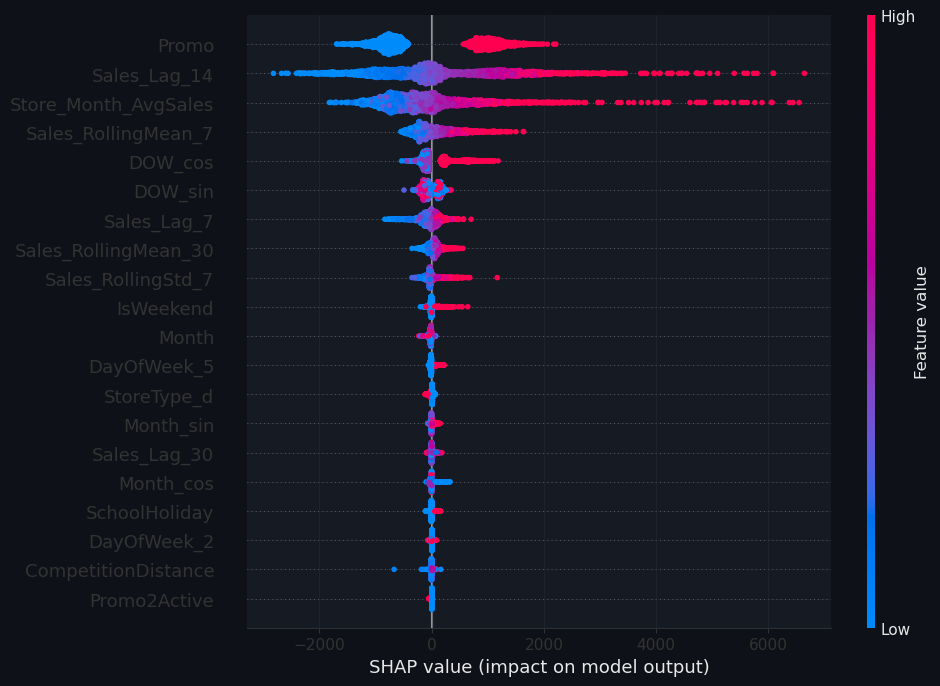

In [31]:
shap.summary_plot(shap_values, X_test_shap, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">17.2 Global Importance — Mean Absolute SHAP Value</h3>
A simpler bar-chart version of the same information: average magnitude of impact per feature, regardless of direction.

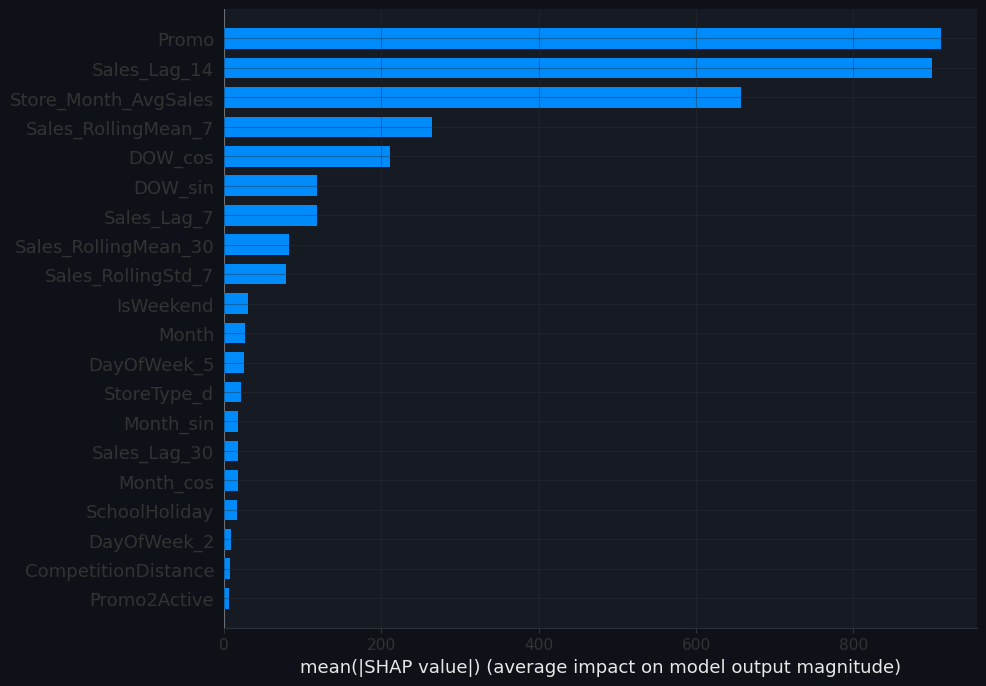

In [32]:
shap.summary_plot(shap_values, X_test_shap, plot_type="bar", show=False)
fig = plt.gcf()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">17.3 Local Explanation — Why This One Prediction?</h3>
A waterfall plot for a single test row, showing exactly how each feature pushed that one prediction up or down from the model's average output. This is the level of explanation a store manager or stakeholder would actually want: "why did the model predict this specific number for this specific day?"

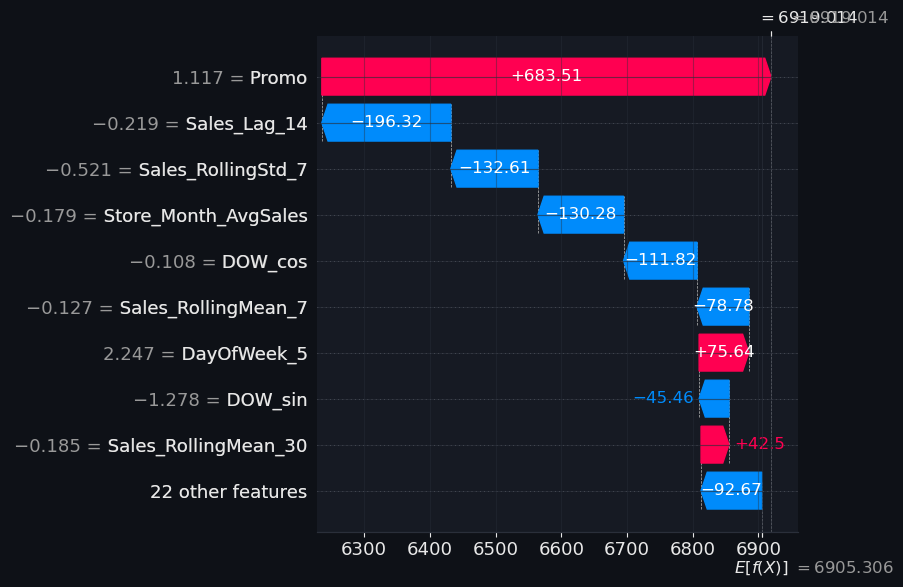

In [33]:
example_row = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[example_row],
        base_values=explainer.expected_value,
        data=X_test_shap.iloc[example_row],
        feature_names=feature_cols,
    ),
    show=False
)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.tight_layout()
plt.show()

<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">17.4 Dependence Plot — How the Top Feature Drives Predictions</h3>
Shows the relationship between one feature's actual value (x-axis) and its SHAP impact (y-axis), colored by whichever second feature it interacts with most. This reveals non-linear effects that a single feature-importance number cannot show (e.g. “this feature only matters once it crosses some threshold”).

Top feature by mean |SHAP value|: Promo


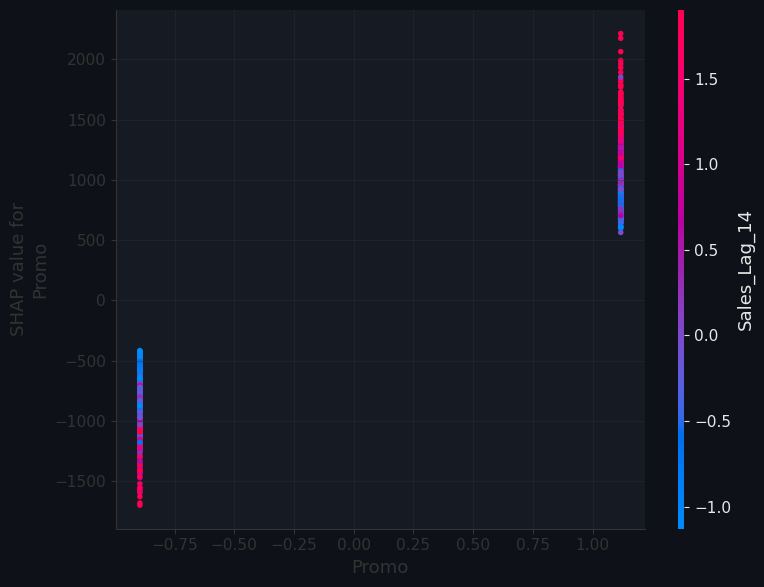

In [34]:
top_feature = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).idxmax()
print(f"Top feature by mean |SHAP value|: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_test_shap, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">18. Permutation Importance</h2>
A model-agnostic cross-check on the SHAP and built-in feature importances above: each feature's values are randomly shuffled one at a time, and the drop in R2 that results is measured. A feature that matters a lot will cause a big drop when scrambled; a feature the model ignores will barely change the score. Unlike SHAP or the tree's own importances, this measures impact directly on real predictive performance rather than on the model's internal structure, so it is a useful independent sanity check.

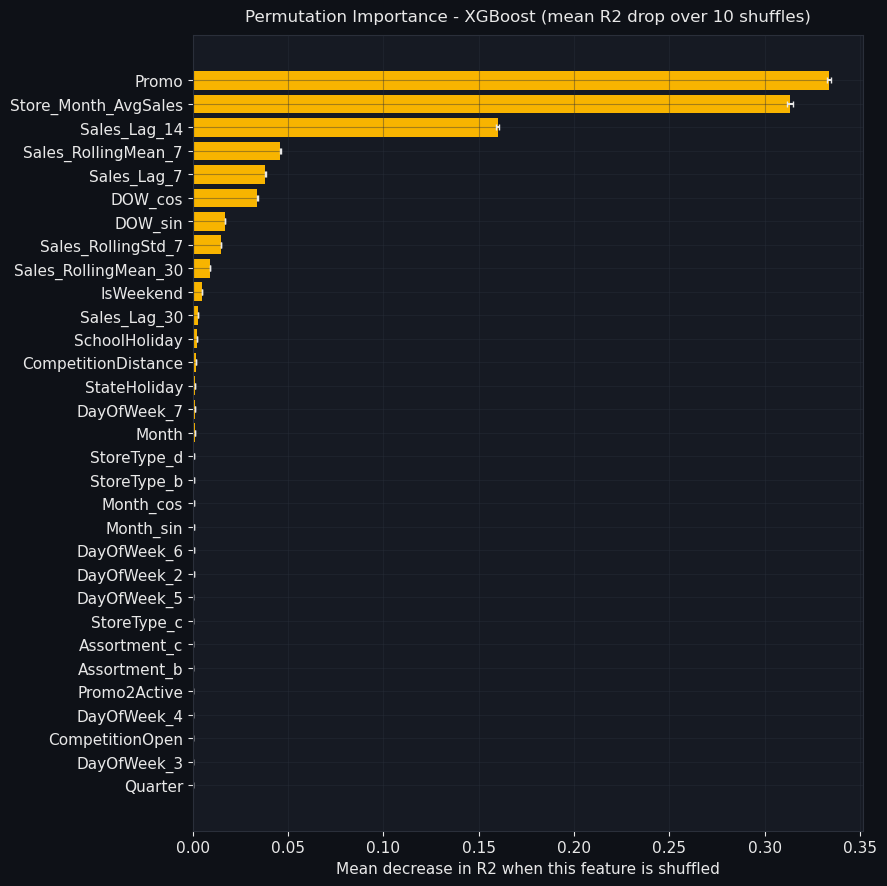

Top 5 by permutation importance:
Promo                   0.333751
Store_Month_AvgSales    0.313157
Sales_Lag_14            0.159978
Sales_RollingMean_7     0.045854
Sales_Lag_7             0.037979
dtype: float64


In [35]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_model, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring="r2"
)

perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=True)
perm_std = pd.Series(perm_result.importances_std, index=feature_cols).reindex(perm_importance.index)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(perm_importance.index, perm_importance.values, xerr=perm_std.values, color=ACCENT[3], ecolor=TEXT_CLR, capsize=2)
ax.set_title("Permutation Importance - XGBoost (mean R2 drop over 10 shuffles)", fontsize=12, pad=10)
ax.set_xlabel("Mean decrease in R2 when this feature is shuffled")
style_spines(ax)
plt.tight_layout()
plt.show()

print("Top 5 by permutation importance:")
print(perm_importance.sort_values(ascending=False).head(5))

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">19. ICE Plots (Individual Conditional Expectation)</h2>
For each of the top 3 features (by feature importance), this shows one thin line per individual test row — how that single row's prediction would change if only this one feature's value were varied, holding everything else about that row fixed. The thick line is the average across all rows (equivalent to a standard Partial Dependence plot). Where the thin lines fan out or cross, different stores/days respond differently to that feature — something a single averaged PDP line alone would hide.

Top 3 features for ICE plots: ['Sales_Lag_14', 'Promo', 'Store_Month_AvgSales']


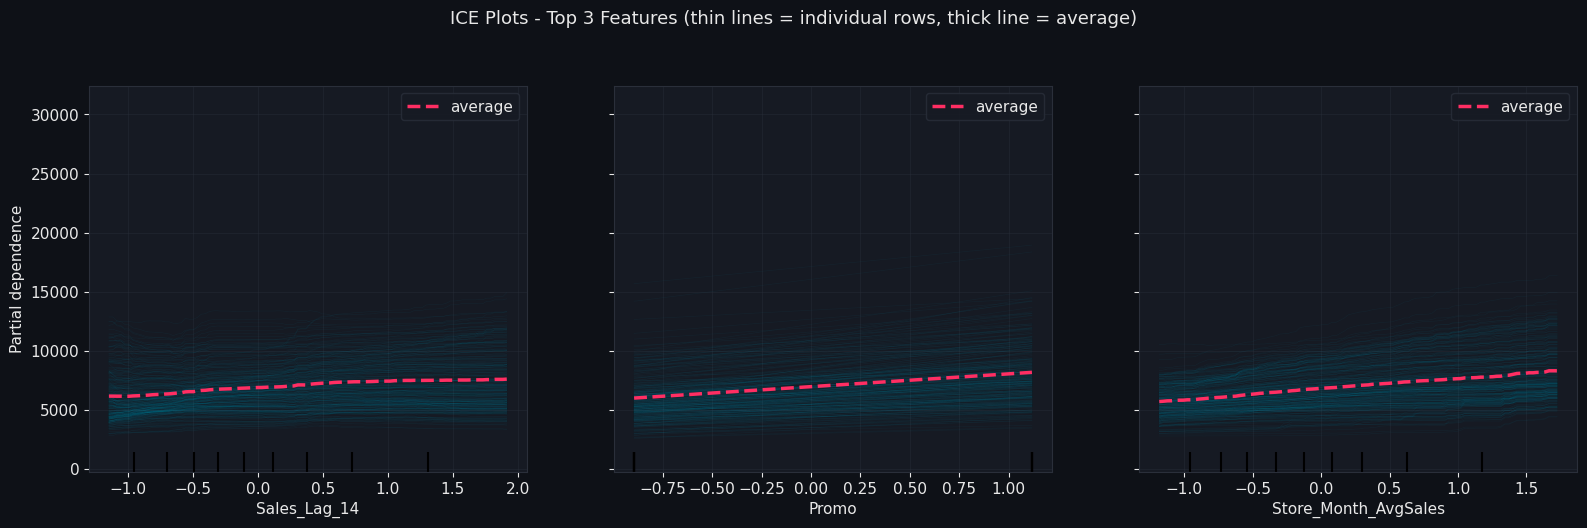

In [36]:
from sklearn.inspection import PartialDependenceDisplay

top3_features = xgb_importance.sort_values(ascending=False).index[:3].tolist()
top3_idx = [feature_cols.index(f) for f in top3_features]
print("Top 3 features for ICE plots:", top3_features)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

display = PartialDependenceDisplay.from_estimator(
    xgb_model, X_test_scaled_df, features=top3_idx, feature_names=feature_cols,
    kind="both",
    ice_lines_kw={"color": ACCENT[0], "alpha": 0.04},
    pd_line_kw={"color": ACCENT[1], "linewidth": 2.5},
    subsample=300, random_state=RANDOM_STATE,
)
fig = plt.gcf()
fig.set_size_inches(16, 5)
fig.suptitle("ICE Plots - Top 3 Features (thin lines = individual rows, thick line = average)", fontsize=13, y=1.05)
for ax in fig.axes:
    style_spines(ax)
plt.tight_layout()
plt.show()

<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">20. Saving the Final Model for Deployment</h2>
The winning model (chosen by highest R2 in Section 12) is bundled together with its fitted `scaler` and the exact `feature_cols` list into a single `.pkl` file. All three are needed together at prediction time — saving the model alone is not enough, since raw inputs must go through the *same* scaler and be arranged in the *same* feature order before the model can use them.

In [38]:
import joblib

_available_models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

if best_model_name == "Ensemble (RF + XGB)":

    deployment_package = {
        "model_type": "ensemble_average",
        "models": {"random_forest": rf_model, "xgboost": xgb_model},
        "ensemble_rule": "prediction = (random_forest.predict(X) + xgboost.predict(X)) / 2",
        "scaler": scaler,
        "feature_cols": feature_cols,
    }
else:
    deployment_package = {
        "model_type": best_model_name,
        "model": _available_models[best_model_name],
        "scaler": scaler,
        "feature_cols": feature_cols,
    }

OUTPUT_PATH = "rossmann_sales_model.pkl"
joblib.dump(deployment_package, OUTPUT_PATH)

print(f"Saved deployment package to {OUTPUT_PATH}")
print(f"Model type: {deployment_package['model_type']}")
print(f"Number of features expected at inference time: {len(feature_cols)}")

Saved deployment package to rossmann_sales_model.pkl
Model type: Random Forest
Number of features expected at inference time: 31


<h3 style="font-size:18px; font-weight:700; margin-top:12px; margin-bottom:6px;">20.1 How to Load and Use This File Later</h3>
This is exactly how the saved `.pkl` would be loaded in a separate deployment script or API, without needing this notebook at all.

In [39]:
# Example of how to reuse the saved model elsewhere (e.g. in a deployment script):
#
# import joblib
# package = joblib.load("rossmann_sales_model.pkl")
#
# new_rows = new_rows[package["feature_cols"]]        # same columns, same order
# new_rows_scaled = package["scaler"].transform(new_rows)  # transform(), never fit_transform()
#
# if package["model_type"] == "ensemble_average":
#     rf_pred = package["models"]["random_forest"].predict(new_rows_scaled)
#     xgb_pred = package["models"]["xgboost"].predict(new_rows_scaled)
#     final_prediction = (rf_pred + xgb_pred) / 2
# else:
#     final_prediction = package["model"].predict(new_rows_scaled)

print("See the commented example above for how to reuse this file in a deployment script.")

See the commented example above for how to reuse this file in a deployment script.


<h2 style="font-size:23px; font-weight:800; margin-top:22px; margin-bottom:8px; border-bottom:2px solid #4a4f5b; padding-bottom:5px;">21. Conclusion</h2>

**Selection criterion:** the model with the highest R2 and lowest RMSE/MAE on the chronological hold-out set is the strongest candidate, since it generalizes best to genuinely unseen future dates.

**What to expect:**
- Linear Regression should score noticeably lower than the tree-based models - it cannot capture non-linear promo/holiday interactions the way trees can.
- Random Forest and XGBoost should both score much higher, since they exploit the strong lag/rolling features (Sales_Lag_14, Store_Month_AvgSales, etc.) directly.
- The Ensemble (average of RF + XGBoost) will often edge out both individual models slightly, though not always by much.

**If R2 comes out below the ~0.98 target:**
1. Increase `n_iter` in the `RandomizedSearchCV` calls (more hyperparameter combinations tried).
2. Try stacking instead of simple averaging for the ensemble (a small meta-model learns the best combination weights instead of a fixed 50/50 average).
3. Consider per-store or per-StoreType models instead of one global model, since different store types may have different sales dynamics.
4. Revisit whether `Customers` (or a reliable estimate of it) can be safely included - it was the single strongest correlate of Sales in Milestone 2, but is not usually known ahead of time in real deployment, so it was intentionally excluded from `feature_cols` here.

**Deployment note:** whichever model is chosen, save it together with the fitted `scaler` and the exact `feature_cols` list, since all three must be reused identically at prediction time.